In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (update path if needed)
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('credit_risk_dataset.csv')

df.head()

Saving credit_risk_dataset.csv to credit_risk_dataset.csv


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


((32581, 12), None)

In [ ]:
df['loan_status'].value_counts(normalize=True)

,proportion
loan_status,
0,0.781836
1,0.218164


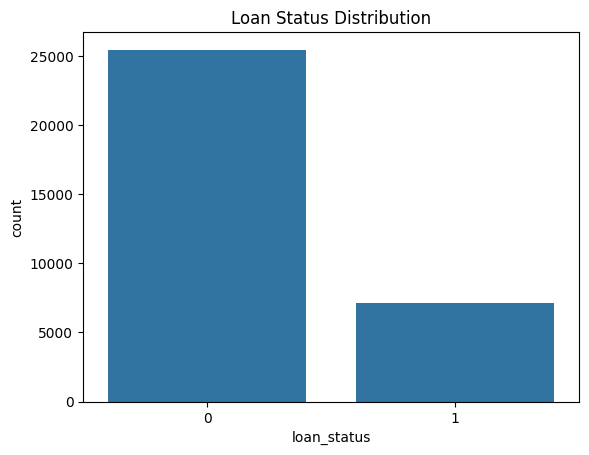

In [ ]:
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.show()

##Missing Value Analysis

In [ ]:
df.isnull().mean().sort_values(ascending=False)

,0
loan_int_rate,0.095639
person_emp_length,0.027470
person_income,0.000000
person_age,0.000000
person_home_ownership,0.000000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_status,0.000000
loan_percent_income,0.000000


##Numerical Feature Analysis

In [ ]:
num_cols = ['person_age','person_income','person_emp_length','loan_amnt',
            'loan_int_rate','loan_percent_income','cb_person_cred_hist_length']

df[num_cols].describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000


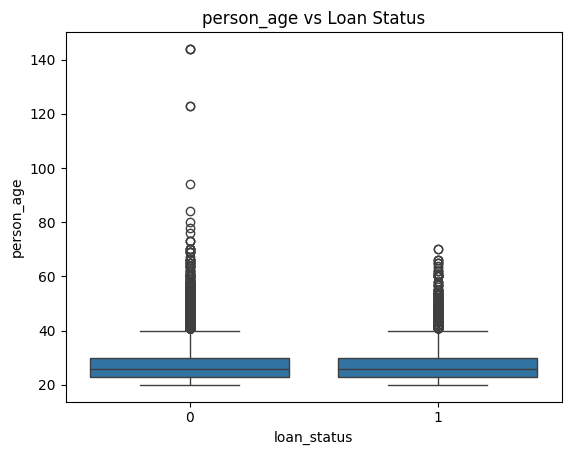

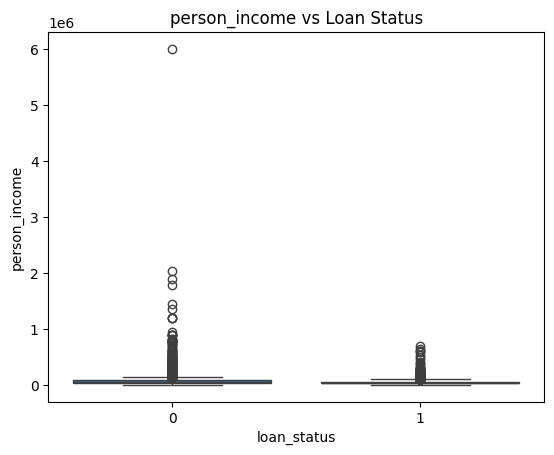

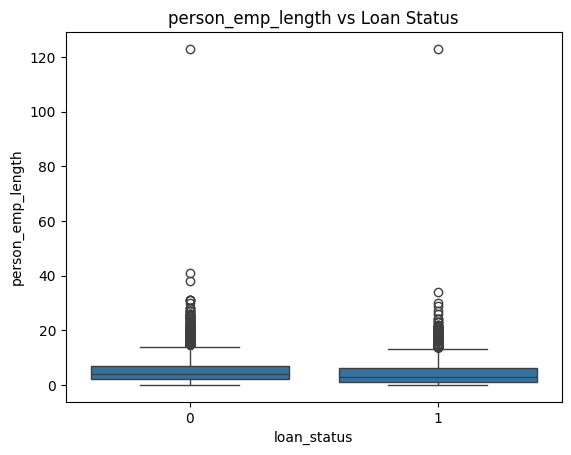

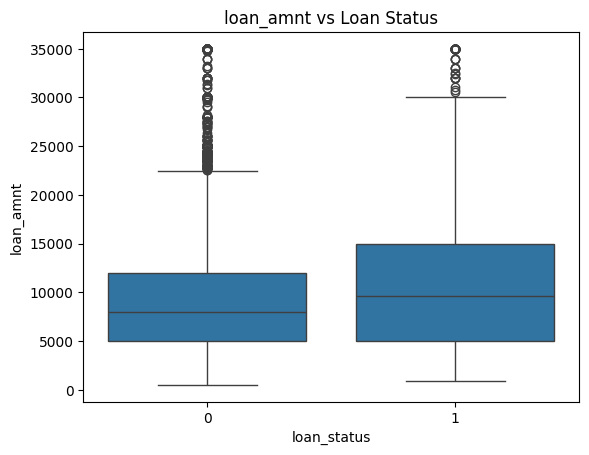

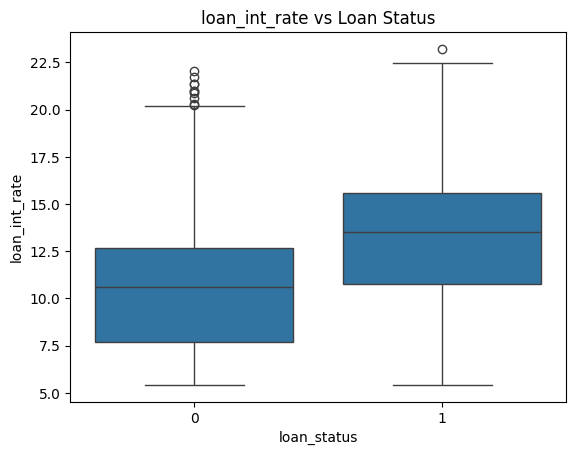

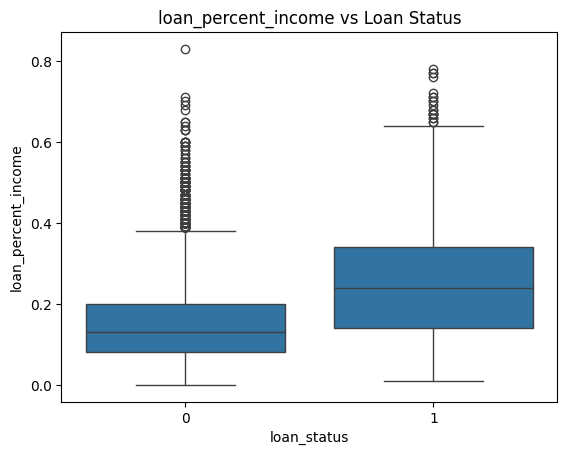

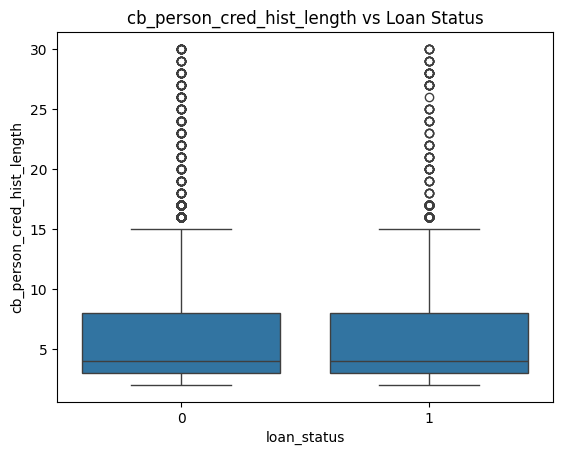

In [ ]:
for col in num_cols:
    sns.boxplot(x='loan_status', y=col, data=df)
    plt.title(f'{col} vs Loan Status')
    plt.show()

##Categorical Feature Analysis

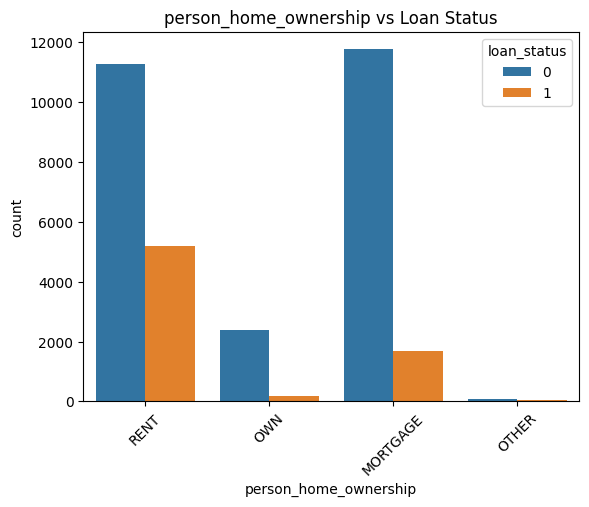

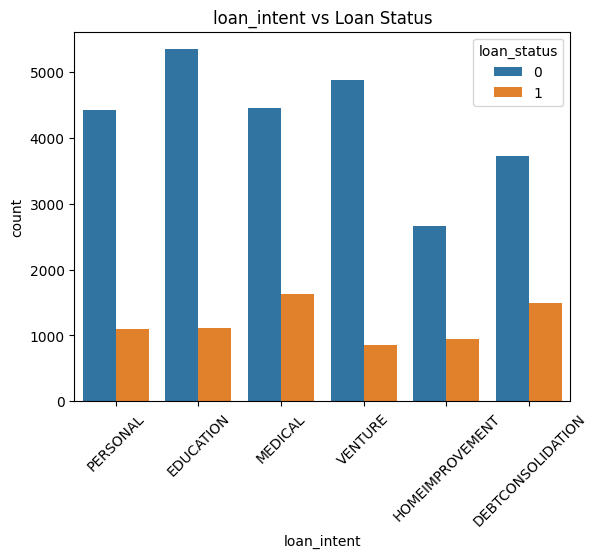

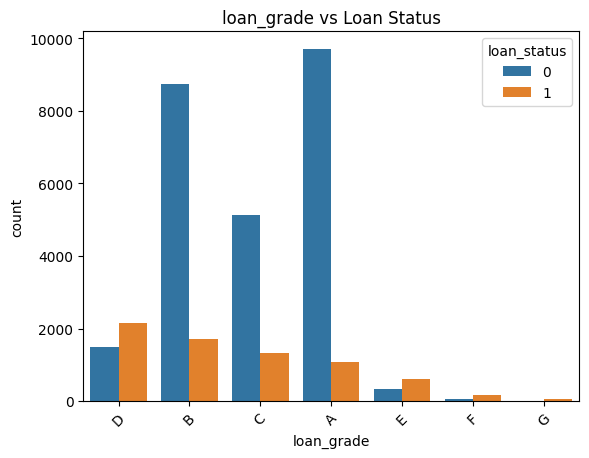

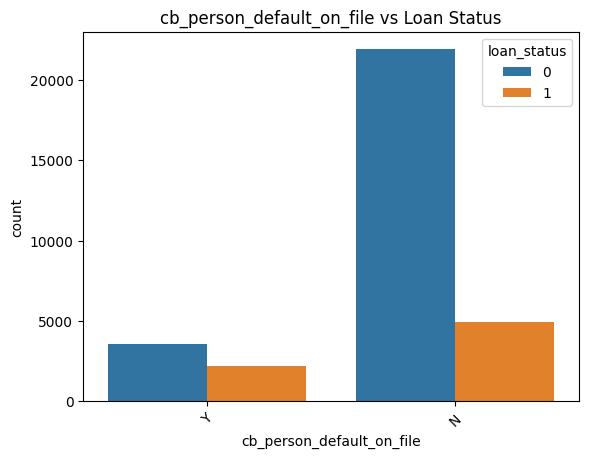

In [ ]:
cat_cols = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']

for col in cat_cols:
    sns.countplot(x=col, hue='loan_status', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Loan Status')
    plt.show()

##Correlation Analysis

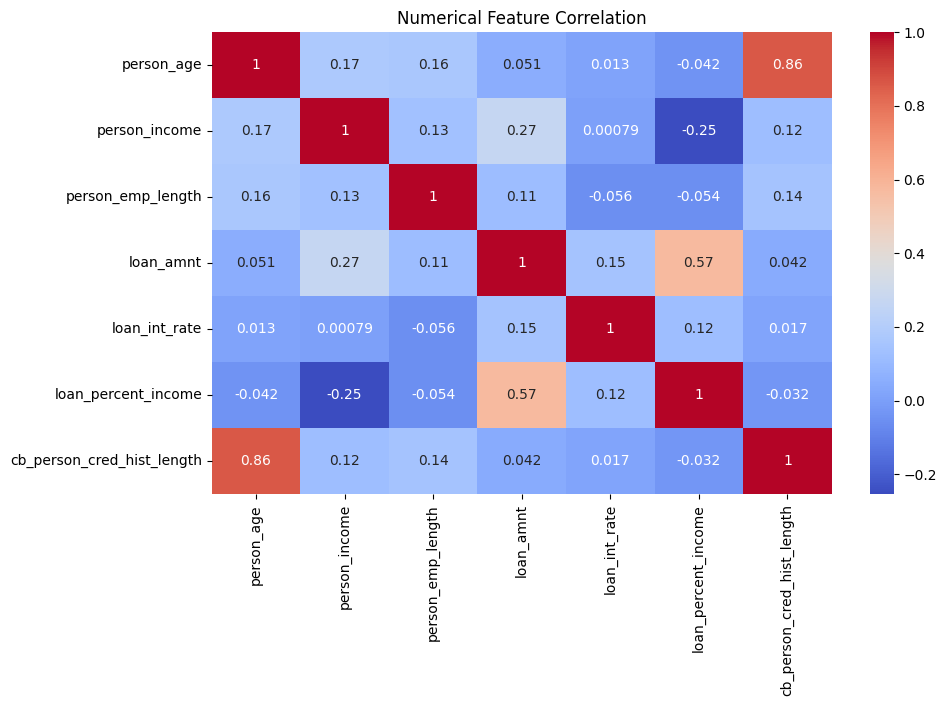

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Numerical Feature Correlation')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
target = 'loan_status'

num_cols = ['person_age','person_income','person_emp_length','loan_amnt',
            'loan_int_rate','loan_percent_income','cb_person_cred_hist_length']

cat_cols = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']

In [ ]:
X = df[num_cols + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

grade_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['A','B','C','D','E','F','G']]))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('grade', grade_pipeline, ['loan_grade']),
    ('cat', cat_pipeline, list(set(cat_cols) - {'loan_grade'}))
])

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((26064, 20), (6517, 20))

# Modeling & Evaluation

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

## Baseline Model: Logistic Regression

In [ ]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_processed, y_train)

train_pred_lr = log_model.predict_proba(X_train_processed)[:,1]
test_pred_lr = log_model.predict_proba(X_test_processed)[:,1]

print('Train ROC-AUC:', roc_auc_score(y_train, train_pred_lr))
print('Test ROC-AUC:', roc_auc_score(y_test, test_pred_lr))

Train ROC-AUC: 0.8444189638208593
Test ROC-AUC: 0.8436287195880244


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## XGBoost Model

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
test_pred_xgb = xgb_model.predict_proba(X_test_processed)[:,1]
print('XGBoost Test ROC-AUC:', roc_auc_score(y_test, test_pred_xgb))

XGBoost Test ROC-AUC: 0.9492236811412968


In [ ]:
threshold = 0.4
y_pred = (test_pred_xgb >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[4625  470]
 [ 226 1196]]
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      5095
           1       0.72      0.84      0.77      1422

    accuracy                           0.89      6517
   macro avg       0.84      0.87      0.85      6517
weighted avg       0.90      0.89      0.90      6517



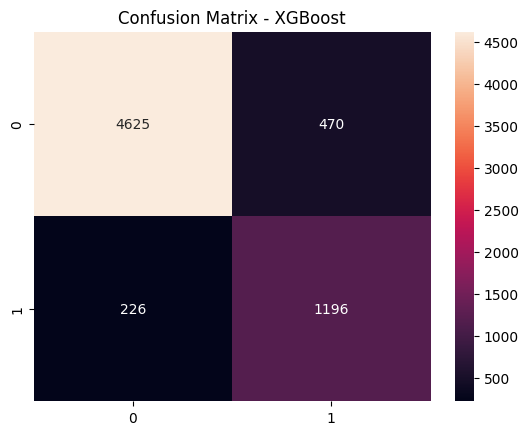

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title('Confusion Matrix - XGBoost')
plt.show()

# Explainability & Credit Risk Scoring

## Load Trained Pipeline

In [ ]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# Load trained pipeline (preprocessing + model)
from google.colab import files
uploaded = files.upload()
pipeline = joblib.load('credit_risk_pipeline.pkl')

Saving credit_risk_pipeline.pkl to credit_risk_pipeline.pkl


/usr/lib/python3.12/pickle.py:1760: UserWarning: [09:20:26] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


## Prepare Data for Explainability

In [ ]:
target = 'loan_status'
X = df.drop(columns=[target])
y = df[target]

# Use a subset for SHAP to reduce computation
X_sample = X.sample(1000, random_state=42)

## SHAP Explainer Setup

In [ ]:
# Extract trained model from pipeline
model = pipeline.named_steps['model']
preprocessor = pipeline.named_steps['preprocessor']

# Transform data
X_sample_processed = preprocessor.transform(X_sample)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample_processed)

## Global Explainability

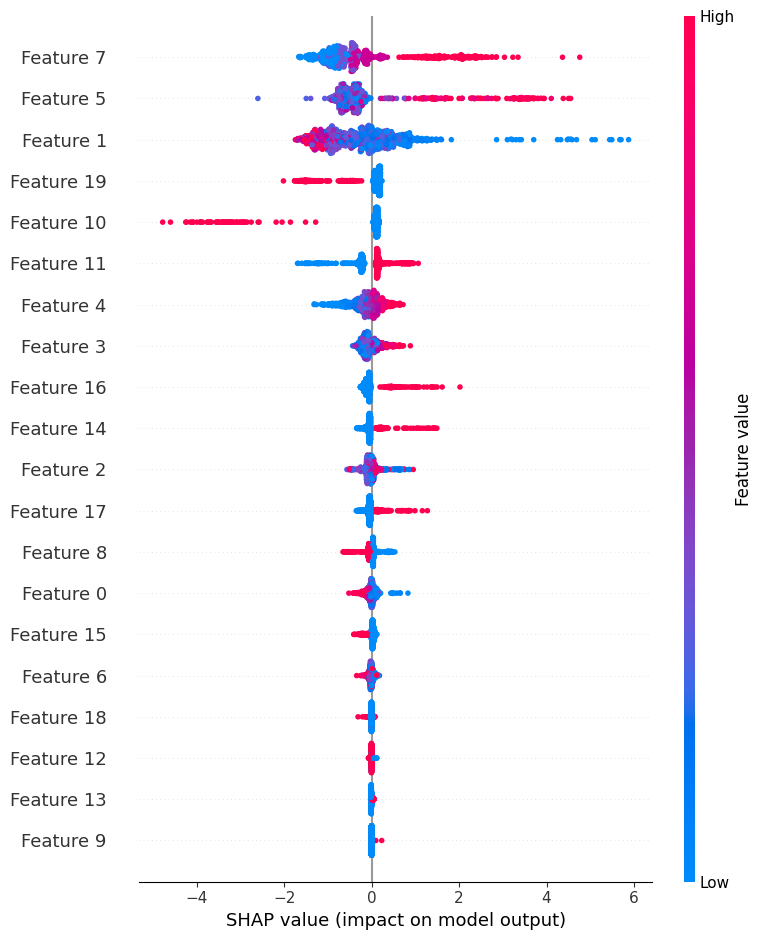

In [ ]:
shap.summary_plot(shap_values, X_sample_processed)

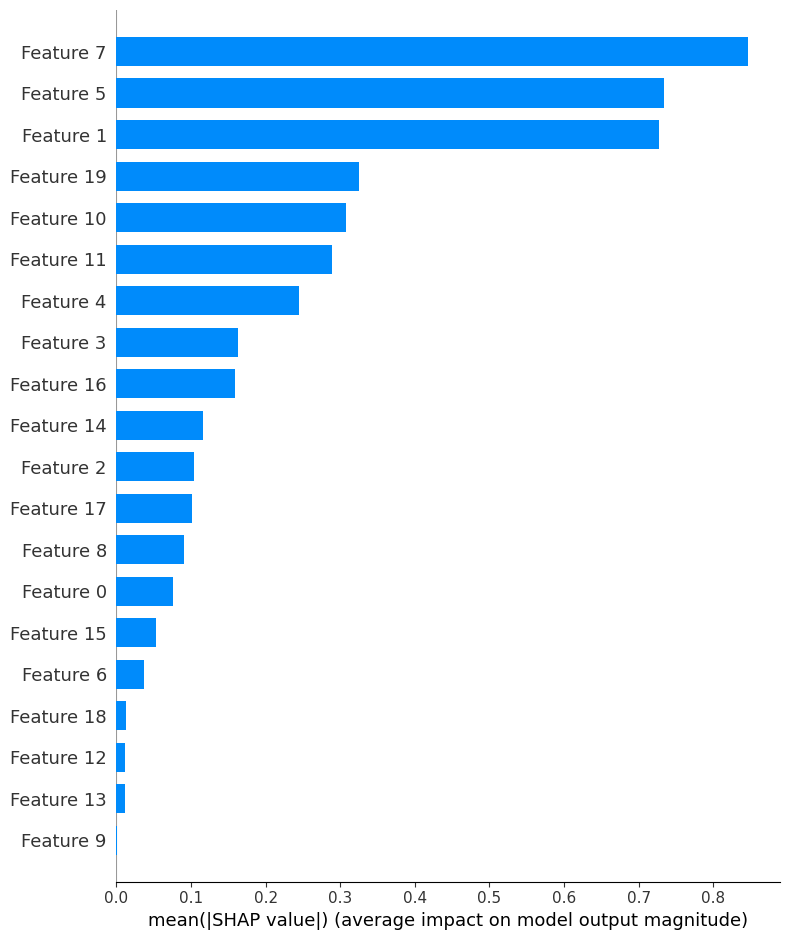

In [ ]:
shap.summary_plot(shap_values, X_sample_processed, plot_type='bar')

## Local Explainability (Single Prediction)

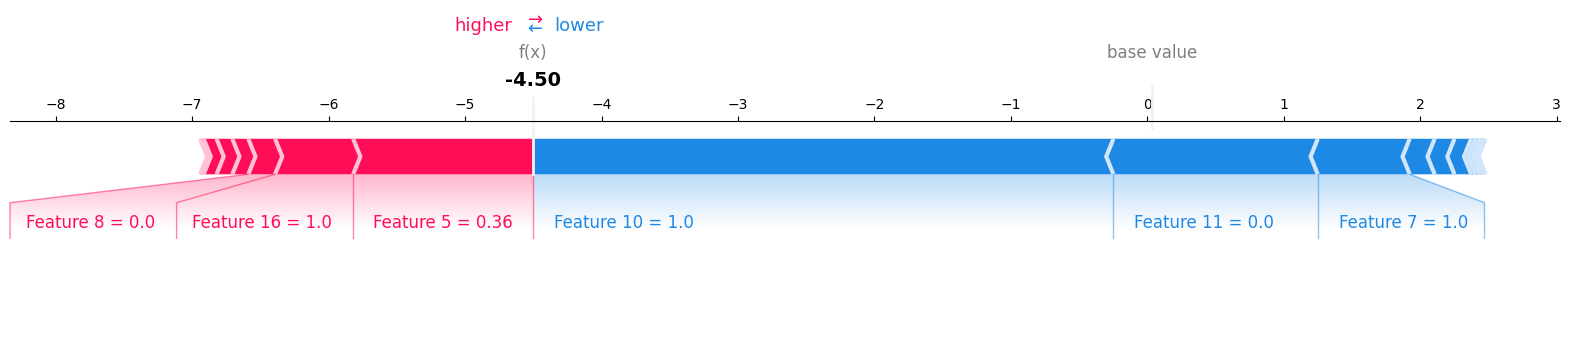

In [ ]:
# Select a single observation
idx = 0
X_single = X_sample.iloc[[idx]]
X_single_processed = preprocessor.transform(X_single)

shap_value_single = explainer.shap_values(X_single_processed)

shap.force_plot(
    explainer.expected_value,
    shap_value_single,
    X_single_processed,
    matplotlib=True
)

## Credit Risk Score Generation

In [ ]:
def credit_risk_score(prob_default):
    return int(100 - prob_default * 100)

def risk_category(score):
    if score >= 80:
        return 'Low Risk'
    elif score >= 60:
        return 'Medium Risk'
    else:
        return 'High Risk'

In [ ]:
# Apply risk scoring to sample predictions
probs = pipeline.predict_proba(X_sample)[:,1]

results = X_sample.copy()
results['prob_default'] = probs
results['risk_score'] = results['prob_default'].apply(credit_risk_score)
results['risk_category'] = results['risk_score'].apply(risk_category)

results.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,prob_default,risk_score,risk_category
14668,24,28000,OWN,6.0,HOMEIMPROVEMENT,B,10000,10.37,0.36,N,2,0.010999,98,Low Risk
24614,27,64000,RENT,0.0,PERSONAL,C,10000,15.27,0.16,Y,10,0.418254,58,High Risk
11096,26,72000,MORTGAGE,10.0,EDUCATION,D,16000,NaN,0.22,N,3,0.334892,66,Medium Risk
10424,23,27996,RENT,7.0,DEBTCONSOLIDATION,A,10000,NaN,0.36,N,2,0.993412,0,High Risk
26007,30,44500,RENT,2.0,MEDICAL,E,13000,16.32,0.29,N,6,0.975249,2,High Risk


## Final Training & Deployment Pipeline

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import joblib

In [ ]:
target = 'loan_status'

num_cols = [
    'person_age','person_income','person_emp_length',
    'loan_amnt','loan_int_rate','loan_percent_income',
    'cb_person_cred_hist_length'
]

cat_cols = [
    'person_home_ownership','loan_intent',
    'loan_grade','cb_person_default_on_file'
]

X = df[num_cols + cat_cols]
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

grade_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['A','B','C','D','E','F','G']]))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('grade', grade_pipeline, ['loan_grade']),
    ('cat', cat_pipeline, list(set(cat_cols) - {'loan_grade'}))
])

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('grade',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordina...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
train_auc = roc_auc_score(y_train, pipeline.predict_proba(X_train)[:,1])
test_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:,1])

train_auc, test_auc

(np.float64(0.9714038898031566), np.float64(0.9492236811412968))

In [ ]:
joblib.dump(pipeline, 'credit_risk_pipeline.pkl')

['credit_risk_pipeline.pkl']

##**Jalanin Streamlit**

In [ ]:
!pip install plotly -q

In [ ]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.8 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from pathlib import Path
from datetime import datetime
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable
from reportlab.lib.enums import TA_CENTER, TA_LEFT
import io

# ---------------- Page Config ----------------
st.set_page_config(
    page_title="Credit Risk Assessment",
    page_icon="💳",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ---------------- Load Model ----------------
@st.cache_resource
def load_pipeline():
    return joblib.load("credit_risk_pipeline.pkl")

pipeline = load_pipeline()

# ---------------- Session State Init ----------------
if "history" not in st.session_state:
    st.session_state.history = []

# ---------------- Feature Importance Data ----------------
FEATURE_NAMES = [
    "person_age", "person_income", "person_emp_length", "person_home_ownership",
    "loan_intent", "loan_grade", "loan_amnt", "loan_int_rate",
    "loan_percent_income", "cb_person_default_on_file", "cb_person_cred_hist_length"
]

FEATURE_EXPLANATIONS = {
    "loan_percent_income": "Loan amount relative to your annual income",
    "loan_int_rate": "Interest rate on the loan",
    "loan_grade": "Creditworthiness grade assigned to the loan",
    "person_income": "Your annual income",
    "loan_amnt": "Total loan amount requested",
    "cb_person_cred_hist_length": "Length of your credit history",
    "person_emp_length": "Years of employment",
    "cb_person_default_on_file": "Previous loan default on record",
    "person_age": "Applicant age",
    "person_home_ownership": "Home ownership status",
    "loan_intent": "Purpose of the loan"
}

#download
def generate_pdf_report(pred: dict) -> bytes:
    buffer = io.BytesIO()
    doc = SimpleDocTemplate(
        buffer, pagesize=A4,
        rightMargin=2*cm, leftMargin=2*cm,
        topMargin=2*cm, bottomMargin=2*cm
    )

    styles = getSampleStyleSheet()
    title_style = ParagraphStyle('Title', parent=styles['Title'], fontSize=20, textColor=colors.HexColor('#1a1a2e'), spaceAfter=6)
    heading_style = ParagraphStyle('Heading', parent=styles['Heading2'], fontSize=13, textColor=colors.HexColor('#16213e'), spaceBefore=14, spaceAfter=6)
    normal_style = ParagraphStyle('Normal', parent=styles['Normal'], fontSize=10, spaceAfter=4)
    caption_style = ParagraphStyle('Caption', parent=styles['Normal'], fontSize=8, textColor=colors.grey)

    risk_color = {
        "Low Risk": colors.HexColor('#2d6a4f'),
        "Medium Risk": colors.HexColor('#b5850a'),
        "High Risk": colors.HexColor('#c1121f'),
    }.get(pred['risk_level'], colors.black)

    story = []

    # Header
    story.append(Paragraph("Credit Risk Assessment Report", title_style))
    story.append(Paragraph(f"Generated: {datetime.now().strftime('%d %B %Y, %H:%M:%S')}", caption_style))
    story.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#cccccc'), spaceAfter=12))

    # Summary Box
    story.append(Paragraph("Assessment Summary", heading_style))

    decision_icon = {"Low Risk": "APPROVED", "Medium Risk": "REVIEW REQUIRED", "High Risk": "REJECTED"}.get(pred['risk_level'], "-")
    summary_data = [
        ["Metric", "Value"],
        ["Credit Risk Score", f"{pred['risk_score']} / 100"],
        ["Default Probability", f"{pred['prob_default']:.1%}"],
        ["Risk Level", pred['risk_level']],
        ["Recommendation", decision_icon],
    ]
    summary_table = Table(summary_data, colWidths=[8*cm, 8*cm])
    summary_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#16213e')),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, -1), 10),
        ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.HexColor('#f8f9fa'), colors.white]),
        ('TEXTCOLOR', (1, 3), (1, 3), risk_color),
        ('FONTNAME', (1, 3), (1, 3), 'Helvetica-Bold'),
        ('TEXTCOLOR', (1, 4), (1, 4), risk_color),
        ('FONTNAME', (1, 4), (1, 4), 'Helvetica-Bold'),
        ('BOX', (0, 0), (-1, -1), 0.5, colors.HexColor('#cccccc')),
        ('INNERGRID', (0, 0), (-1, -1), 0.25, colors.HexColor('#dddddd')),
        ('PADDING', (0, 0), (-1, -1), 6),
    ]))
    story.append(summary_table)
    story.append(Spacer(1, 0.4*cm))

    # Applicant Details
    story.append(Paragraph("Applicant Details", heading_style))
    data = pred['input_data']
    personal_data = [
        ["Field", "Value"],
        ["Age", str(data.get('person_age', '-'))],
        ["Annual Income", f"${data.get('person_income', 0):,}"],
        ["Employment Length", f"{data.get('person_emp_length', '-')} years"],
        ["Home Ownership", str(data.get('person_home_ownership', '-'))],
    ]
    personal_table = Table(personal_data, colWidths=[8*cm, 8*cm])
    personal_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#457b9d')),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, -1), 10),
        ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.HexColor('#f8f9fa'), colors.white]),
        ('BOX', (0, 0), (-1, -1), 0.5, colors.HexColor('#cccccc')),
        ('INNERGRID', (0, 0), (-1, -1), 0.25, colors.HexColor('#dddddd')),
        ('PADDING', (0, 0), (-1, -1), 6),
    ]))
    story.append(personal_table)
    story.append(Spacer(1, 0.3*cm))

    # Loan Details
    story.append(Paragraph("Loan Details", heading_style))
    loan_data = [
        ["Field", "Value"],
        ["Loan Purpose", str(data.get('loan_intent', '-'))],
        ["Loan Grade", str(data.get('loan_grade', '-'))],
        ["Loan Amount", f"${data.get('loan_amnt', 0):,}"],
        ["Interest Rate", f"{data.get('loan_int_rate', 0):.1f}%"],
        ["Loan % of Income", f"{data.get('loan_percent_income', 0):.1%}"],
    ]
    loan_table = Table(loan_data, colWidths=[8*cm, 8*cm])
    loan_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#457b9d')),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, -1), 10),
        ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.HexColor('#f8f9fa'), colors.white]),
        ('BOX', (0, 0), (-1, -1), 0.5, colors.HexColor('#cccccc')),
        ('INNERGRID', (0, 0), (-1, -1), 0.25, colors.HexColor('#dddddd')),
        ('PADDING', (0, 0), (-1, -1), 6),
    ]))
    story.append(loan_table)
    story.append(Spacer(1, 0.3*cm))

    # Credit History
    story.append(Paragraph("Credit History", heading_style))
    credit_data = [
        ["Field", "Value"],
        ["Previous Default on Record", "Yes" if data.get('cb_person_default_on_file') == 'Y' else "No"],
        ["Credit History Length", f"{data.get('cb_person_cred_hist_length', '-')} years"],
    ]
    credit_table = Table(credit_data, colWidths=[8*cm, 8*cm])
    credit_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#457b9d')),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, -1), 10),
        ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.HexColor('#f8f9fa'), colors.white]),
        ('BOX', (0, 0), (-1, -1), 0.5, colors.HexColor('#cccccc')),
        ('INNERGRID', (0, 0), (-1, -1), 0.25, colors.HexColor('#dddddd')),
        ('PADDING', (0, 0), (-1, -1), 6),
    ]))
    story.append(credit_table)

    # Footer
    story.append(Spacer(1, 1*cm))
    story.append(HRFlowable(width="100%", thickness=0.5, color=colors.HexColor('#cccccc')))
    story.append(Paragraph("This report is generated automatically by the Credit Risk Assessment system. For internal use only.", caption_style))

    doc.build(story)
    buffer.seek(0)
    return buffer.getvalue()

# ---------------- Header ----------------
st.title("💳 Credit Risk Assessment")

# ---------------- Sidebar Inputs ----------------
st.sidebar.header("📋 Applicant Information")

# Personal Information
with st.sidebar.expander("👤 Personal Details", expanded=True):
    person_age = st.number_input("Age", min_value=18, max_value=100, value=30)
    person_income = st.number_input("Annual Income ($)", min_value=1000, value=50000, step=1000)
    person_emp_length = st.number_input("Employment Length (Years)", min_value=0.0, max_value=50.0, value=5.0, step=0.5)
    person_home_ownership = st.selectbox(
        "Home Ownership", ["RENT", "OWN", "MORTGAGE", "OTHER"]
    )

# Loan Details
with st.sidebar.expander("💰 Loan Details", expanded=True):
    loan_intent = st.selectbox(
        "Loan Purpose",
        ["PERSONAL", "EDUCATION", "MEDICAL", "VENTURE", "HOMEIMPROVEMENT", "DEBTCONSOLIDATION"],
        format_func=lambda x: x.replace("HOMEIMPROVEMENT", "Home Improvement").replace("DEBTCONSOLIDATION", "Debt Consolidation").title()
    )
    loan_grade = st.selectbox(
    "Loan Grade",
    ["A", "B", "C", "D", "E", "F", "G"],
    format_func=lambda x: {
        "A": "A — Very Low Risk",
        "B": "B — Low Risk",
        "C": "C — Moderate Risk",
        "D": "D — Moderately High Risk",
        "E": "E — High Risk",
        "F": "F — Very High Risk",
        "G": "G — Extremely High Risk"
    }[x]
)
    loan_amnt = st.number_input("Loan Amount ($)", min_value=500, value=10000, step=500)
    loan_int_rate = st.number_input("Interest Rate (%)", min_value=0.0, max_value=30.0, value=10.0, step=0.5)
    loan_percent_income = st.slider("Loan as % of Income", 0.0, 1.0, 0.2, 0.01)

# Credit History
with st.sidebar.expander("📊 Credit History", expanded=True):
    cb_person_default_on_file = st.selectbox("Previous Default on Record", ["N", "Y"], format_func=lambda x: "Yes" if x == "Y" else "No")
    cb_person_cred_hist_length = st.number_input("Credit History Length (Years)", min_value=0, max_value=50, value=5)

st.sidebar.divider()
predict_button = st.sidebar.button("🔍 Assess Credit Risk", type="primary")

# ---------------- Main Content Tabs ----------------
tab_results, tab_explain, tab_history, tab_whatif , tab_calc = st.tabs([
    "📊 Results", "🔍 Explanation", "📜 History", "🎛️ What If", "🧮 Loan Calculator"
])

# ---------------- Prediction Logic ----------------
if predict_button:
    input_df = pd.DataFrame([{
        "person_age": person_age,
        "person_income": person_income,
        "person_emp_length": person_emp_length,
        "person_home_ownership": person_home_ownership,
        "loan_intent": loan_intent,
        "loan_grade": loan_grade,
        "loan_amnt": loan_amnt,
        "loan_int_rate": loan_int_rate,
        "loan_percent_income": loan_percent_income,
        "cb_person_default_on_file": cb_person_default_on_file,
        "cb_person_cred_hist_length": cb_person_cred_hist_length,
    }])

    prob_default = pipeline.predict_proba(input_df)[0][1]
    risk_score = int(100 - prob_default * 100)

    if risk_score >= 80:
        risk_level, decision, color = "Low Risk", "Approved", "🟢"
    elif risk_score >= 60:
        risk_level, decision, color = "Medium Risk", "Review Required", "🟡"
    else:
        risk_level, decision, color = "High Risk", "Rejected", "🔴"

    # Store in session state
    st.session_state.last_prediction = {
        "prob_default": prob_default,
        "risk_score": risk_score,
        "risk_level": risk_level,
        "decision": decision,
        "color": color,
        "input_data": input_df.iloc[0].to_dict()
    }

    # Add to history
    st.session_state.history.append({
        "Timestamp": datetime.now().strftime("%H:%M:%S"),
        "Score": risk_score,
        "Risk Level": risk_level,
        "Decision": decision,
        "Loan Amount": f"${loan_amnt:,}",
        "Income": f"${person_income:,}"
    })

# ---------------- Results Tab ----------------
with tab_results:
    if "last_prediction" in st.session_state:
        pred = st.session_state.last_prediction

        st.subheader("Assessment Summary")

        col1, col2, col3 = st.columns(3)
        with col1:
            st.metric("Default Probability", f"{pred['prob_default']:.1%}")
        with col2:
            st.metric("Credit Risk Score", f"{pred['risk_score']}/100")
        with col3:
            st.metric("Recommendation", f"{pred['color']} {pred['decision']}")

        st.divider()

        # Visual Risk Gauge
        st.subheader("Risk Score Gauge")
        score = pred['risk_score']
        st.progress(score / 100)

        col_gauge1, col_gauge2, col_gauge3 = st.columns(3)
        col_gauge1.caption("🔴 High Risk (0-59)")
        col_gauge2.caption("🟡 Medium Risk (60-79)")
        col_gauge3.caption("🟢 Low Risk (80-100)")

        # Risk Category Display
        if pred['risk_level'] == "Low Risk":
            st.success(f"✅ **{pred['risk_level']}**: This applicant shows strong creditworthiness indicators.")
        elif pred['risk_level'] == "Medium Risk":
            st.warning(f"⚠️ **{pred['risk_level']}**: This application requires additional review before approval.")
        else:
            st.error(f"❌ **{pred['risk_level']}**: This applicant shows elevated default risk indicators.")
            # Download PDF Button
        st.divider()
        pdf_bytes = generate_pdf_report(pred)
        st.download_button(
            label="📄 Download PDF Report",
            data=pdf_bytes,
            file_name=f"credit_risk_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf",
            mime="application/pdf",
            type="secondary"
        )

    else:
        st.info("👈 Enter applicant details in the sidebar and click **Assess Credit Risk** to see results.")

# ---------------- Explanation Tab ----------------
with tab_explain:
    if "last_prediction" in st.session_state:
        st.subheader("Understanding the Assessment")

        st.markdown("""
        The credit risk score is calculated by analyzing multiple factors about the applicant
        and their loan request. Here are the key factors that typically influence the assessment:
        """)

        # Get feature importances from the model
        try:
            # Access the XGBoost model from the pipeline
            model = pipeline.named_steps.get('classifier') or pipeline.named_steps.get('model') or pipeline[-1]
            if hasattr(model, 'feature_importances_'):
                importances = model.feature_importances_

                # Get preprocessor output feature names if available
                try:
                    preprocessor = pipeline.named_steps.get('preprocessor') or pipeline[0]
                    feature_names = preprocessor.get_feature_names_out()
                except:
                    feature_names = FEATURE_NAMES

                # Create importance DataFrame
                importance_df = pd.DataFrame({
                    'Feature': feature_names[:len(importances)],
                    'Importance': importances
                }).sort_values('Importance', ascending=False)

                # Top 3 Features
                st.markdown("### 🎯 Top 3 Contributing Factors")

                top_features = importance_df.head(3)
                for i, (_, row) in enumerate(top_features.iterrows(), 1):
                    feature = row['Feature']
                    # Clean feature name for display
                    display_name = feature.split('__')[-1] if '__' in feature else feature
                    display_name = display_name.replace('_', ' ').title()

                    # Get explanation
                    base_feature = feature.split('__')[0] if '__' in feature else feature
                    explanation = FEATURE_EXPLANATIONS.get(base_feature, "This factor influences the risk assessment")

                    st.markdown(f"**{i}. {display_name}**")
                    st.caption(explanation)
                    st.progress(float(row['Importance']))
                    st.write("")

                # Feature Importance Chart (in expander)
                with st.expander("📊 Full Feature Importance Chart"):
                    fig, ax = plt.subplots(figsize=(10, 6))

                    top_10 = importance_df.head(10)
                    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_10)))[::-1]

                    bars = ax.barh(range(len(top_10)), top_10['Importance'].values, color=colors)
                    ax.set_yticks(range(len(top_10)))

                    # Clean labels
                    labels = [f.split('__')[-1].replace('_', ' ').title() for f in top_10['Feature']]
                    ax.set_yticklabels(labels)

                    ax.set_xlabel('Importance Score')
                    ax.set_title('Top 10 Features by Importance')
                    ax.invert_yaxis()

                    plt.tight_layout()
                    st.pyplot(fig)
                    plt.close()

            else:
                st.info("Feature importance data is not available for this model type.")

        except Exception as e:
            st.warning("Unable to extract feature importances from the model.")

        # SHAP section (optional, behind expander)
        with st.expander("🔬 Advanced: SHAP Analysis"):
            st.markdown("""
            **SHAP (SHapley Additive exPlanations)** provides detailed per-prediction explanations.

            For performance reasons, SHAP analysis is not computed by default.
            To enable SHAP visualizations, you can:
            1. Run the explainability notebook locally
            2. Generate SHAP values for specific predictions

            This ensures the app remains fast and responsive on Streamlit Cloud.
            """)
    else:
        st.info("👈 Make a prediction first to see the explanation.")

# ---------------- History Tab ----------------
with tab_history:
    st.subheader("📜 Prediction History")
    st.caption("Recent assessments from this session (stored in memory only)")

    if st.session_state.history:
        history_df = pd.DataFrame(st.session_state.history)
        st.dataframe(history_df, hide_index=True)

        col_clear, col_count = st.columns([1, 3])
        with col_clear:
            if st.button("🗑️ Clear History"):
                st.session_state.history = []
                if "last_prediction" in st.session_state:
                    del st.session_state.last_prediction
                st.rerun()
        with col_count:
            st.caption(f"Total predictions: {len(st.session_state.history)}")
    else:
        st.info("No predictions yet. Make an assessment to see history.")

# ---------------- What If Tab ----------------
with tab_whatif:
    st.subheader("🎛️ What-If Simulator")
    st.caption("Simulate changes in variables and see their impact on the risk score in real time.")

    if "last_prediction" not in st.session_state:
        st.info("👈 Make a prediction first in the sidebar, then return to this tab for simulation.")
    else:
        base = st.session_state.last_prediction["input_data"]

        st.markdown("##### Baseline (from the latest prediction)")
        col_b1, col_b2, col_b3 = st.columns(3)
        col_b1.metric("Income", f"${base['person_income']:,}")
        col_b2.metric("Loan Amount", f"${base['loan_amnt']:,}")
        col_b3.metric("Base Score", f"{st.session_state.last_prediction['risk_score']}/100")

        st.divider()
        st.markdown("##### Adjust the sliders to run a simulation")

        # ---- Sliders ----
        wif_col1, wif_col2 = st.columns(2)

        with wif_col1:
            sim_income = st.slider(
                "Annual Income ($)",
                min_value=10_000,
                max_value=300_000,
                value=int(base["person_income"]),
                step=1_000,
                format="$%d",
                key="wif_income"
            )
            sim_loan_amnt = st.slider(
                "Loan Amount ($)",
                min_value=500,
                max_value=100_000,
                value=int(base["loan_amnt"]),
                step=500,
                format="$%d",
                key="wif_loan_amnt"
            )

        with wif_col2:
            sim_int_rate = st.slider(
                "Interest Rate (%)",
                min_value=0.0,
                max_value=30.0,
                value=float(base["loan_int_rate"]),
                step=0.5,
                format="%.1f%%",
                key="wif_int_rate"
            )
            sim_emp_length = st.slider(
                "Employment Length (Years)",
                min_value=0.0,
                max_value=50.0,
                value=float(base["person_emp_length"]),
                step=0.5,
                format="%.1f yrs",
                key="wif_emp_length"
            )

        # ---- Auto-recalculate loan_percent_income ----
        sim_loan_pct = sim_loan_amnt / sim_income if sim_income > 0 else 0.0

        # ---- Build simulated input ----
        sim_input = pd.DataFrame([{
            **base,
            "person_income": sim_income,
            "loan_amnt": sim_loan_amnt,
            "loan_int_rate": sim_int_rate,
            "person_emp_length": sim_emp_length,
            "loan_percent_income": sim_loan_pct,
        }])

        sim_prob = pipeline.predict_proba(sim_input)[0][1]
        sim_score = int(100 - sim_prob * 100)
        score_delta = sim_score - st.session_state.last_prediction["risk_score"]

        if sim_score >= 80:
            sim_risk, sim_color = "Low Risk", "🟢"
        elif sim_score >= 60:
            sim_risk, sim_color = "Medium Risk", "🟡"
        else:
            sim_risk, sim_color = "High Risk", "🔴"

        st.divider()
        st.markdown("##### Simulation Results")

        res_col1, res_col2, res_col3, res_col4 = st.columns(4)
        res_col1.metric("Simulated Score", f"{sim_score}/100", delta=f"{score_delta:+d} pts")
        res_col2.metric("Default Probability", f"{sim_prob:.1%}")
        res_col3.metric("Risk Level", f"{sim_color} {sim_risk}")
        res_col4.metric("Loan % of Income", f"{sim_loan_pct:.1%}", delta=f"{(sim_loan_pct - base['loan_percent_income']):.1%}")

        # ---- Gauge chart ----
        fig = go.Figure(go.Indicator(
            mode="gauge+number+delta",
            value=sim_score,
            delta={
                "reference": st.session_state.last_prediction["risk_score"],
                "increasing": {"color": "#1D9E75"},
                "decreasing": {"color": "#D85A30"},
            },
            title={"text": "Risk Score", "font": {"size": 16}},
            gauge={
                "axis": {"range": [0, 100], "tickwidth": 1},
                "bar": {"color": "#1D9E75" if sim_score >= 80 else "#BA7517" if sim_score >= 60 else "#D85A30"},
                "steps": [
                    {"range": [0, 59],  "color": "#FAECE7"},
                    {"range": [60, 79], "color": "#FAEEDA"},
                    {"range": [80, 100],"color": "#EAF3DE"},
                ],
                "threshold": {
                    "line": {"color": "#444", "width": 2},
                    "thickness": 0.75,
                    "value": st.session_state.last_prediction["risk_score"],
                }
            }
        ))
        fig.update_layout(height=280, margin=dict(t=40, b=0, l=20, r=20))
        st.plotly_chart(fig, use_container_width=True)
        st.caption("Black line = baseline score. Colored bar = current simulated score.")

        # ---- Smart tips ----
        st.divider()
        st.markdown("##### 💡 Smart tips")

        tips = []

        if sim_loan_pct > 0.4:
            ideal_loan = int(sim_income * 0.3)
            tips.append(f"⚠️ Your Loan % of Income is **{sim_loan_pct:.0%}** — relatively high. "
                        f"Try reducing the loan amount to **${ideal_loan:,}** (30% of income) for a better outcome.")

        if sim_int_rate > 15:
            tips.append(f"📈 The interest rate **{sim_int_rate:.1f}%** is considered high. "
                        f"Try negotiating a rate below 15% to reduce risk.")

        if sim_emp_length < 2:
            tips.append(f"💼 An employment length **{sim_emp_length:.1f} years** is relatively short. "
                        f"Employment stability of 2+ years generally improves creditworthiness.")

        if score_delta > 0:
            tips.append(f"✅ This configuration increases the score by **{score_delta:+d} points** compared to the baseline.")
        elif score_delta < 0:
            tips.append(f"❌ This configuration decreases the score by **{score_delta} points** compared to the baseline.")
        else:
            tips.append("➡️ The score remains unchanged from the baseline.")

        for tip in tips:
            st.markdown(tip)

# ---------------- Loan Calculator Tab ----------------
with tab_calc:
    st.subheader("🧮 Loan Calculator")
    st.caption("Estimate monthly payments and the total cost of the loan.")

    calc_col1, calc_col2 = st.columns(2)

    with calc_col1:
        st.markdown("##### ⚙️ Loan Parameters")

        # Auto-fill dari sidebar kl udh ada prediksi
        default_loan = int(st.session_state.last_prediction["input_data"]["loan_amnt"]) \
            if "last_prediction" in st.session_state else 10000
        default_rate = float(st.session_state.last_prediction["input_data"]["loan_int_rate"]) \
            if "last_prediction" in st.session_state else 10.0

        calc_loan_amnt = st.number_input(
            "Loan Amount ($)", min_value=500, max_value=500_000,
            value=default_loan, step=500, key="calc_loan"
        )
        calc_int_rate = st.number_input(
            "Annual Interest Rate (%)", min_value=0.1, max_value=40.0,
            value=default_rate, step=0.1, key="calc_rate"
        )
        calc_tenure = st.selectbox(
            "Loan Tenure",
            options=[6, 12, 24, 36, 48, 60, 84, 120],
            index=3,
            format_func=lambda x: f"{x} months ({x//12} yr)" if x >= 12 else f"{x} months",
            key="calc_tenure"
        )
        calc_start = st.date_input("Loan Start Date", value=datetime.today(), key="calc_start")

    # ---- Calculation ----
    monthly_rate = (calc_int_rate / 100) / 12
    n = calc_tenure

    if monthly_rate == 0:
        monthly_payment = calc_loan_amnt / n
    else:
        monthly_payment = calc_loan_amnt * (monthly_rate * (1 + monthly_rate)**n) / ((1 + monthly_rate)**n - 1)

    total_payment = monthly_payment * n
    total_interest = total_payment - calc_loan_amnt

    with calc_col2:
        st.markdown("##### 📊 Calculation Results")

        st.metric("Monthly Payment", f"${monthly_payment:,.2f}")
        st.metric("Total Payment", f"${total_payment:,.2f}")
        st.metric("Total Interest", f"${total_interest:,.2f}",
                  delta=f"{(total_interest/calc_loan_amnt)*100:.1f}% of principal",
                  delta_color="inverse")

        # Interest vs Principal donut
        fig_donut = go.Figure(go.Pie(
            labels=["Principal", "Total Interest"],
            values=[calc_loan_amnt, total_interest],
            hole=0.55,
            marker_colors=["#1D9E75", "#D85A30"],
            textinfo="label+percent",
            hovertemplate="%{label}: $%{value:,.2f}<extra></extra>"
        ))
        fig_donut.update_layout(
            height=240,
            margin=dict(t=20, b=0, l=0, r=0),
            showlegend=False,
            annotations=[dict(text=f"${calc_loan_amnt:,}", x=0.5, y=0.5,
                              font_size=14, showarrow=False)]
        )
        st.plotly_chart(fig_donut, use_container_width=True)

    st.divider()

    # ---- Amortization Schedule ----
    st.markdown("##### 📅 Amortization Schedule")

    balance = calc_loan_amnt
    schedule = []
    current_date = calc_start.replace(day=1)

    import calendar
    from dateutil.relativedelta import relativedelta

    for i in range(1, n + 1):
        interest_payment = balance * monthly_rate
        principal_payment = monthly_payment - interest_payment
        balance -= principal_payment
        balance = max(balance, 0)

        payment_date = calc_start.replace(day=1) + relativedelta(months=i)

        schedule.append({
            "Month": i,
            "Date": payment_date.strftime("%b %Y"),
            "Payment ($)": round(monthly_payment, 2),
            "Principal ($)": round(principal_payment, 2),
            "Interest ($)": round(interest_payment, 2),
            "Balance ($)": round(balance, 2),
        })

    amort_df = pd.DataFrame(schedule)

    # Chart: Principal vs Interest over time
    fig_area = go.Figure()
    fig_area.add_trace(go.Scatter(
        x=amort_df["Month"], y=amort_df["Principal ($)"],
        name="Principal", fill='tozeroy',
        line=dict(color="#1D9E75"), fillcolor="rgba(29,158,117,0.25)"
    ))
    fig_area.add_trace(go.Scatter(
        x=amort_df["Month"], y=amort_df["Interest ($)"],
        name="Interest", fill='tozeroy',
        line=dict(color="#D85A30"), fillcolor="rgba(216,90,48,0.2)"
    ))
    fig_area.update_layout(
        height=260,
        margin=dict(t=20, b=30, l=40, r=20),
        xaxis_title="Month",
        yaxis_title="Amount ($)",
        legend=dict(orientation="h", y=1.1),
    )
    st.plotly_chart(fig_area, use_container_width=True)

    # Table — show collapsible
    with st.expander("📋 View Full Table"):
        st.dataframe(
            amort_df.style.format({
                "Payment ($)": "${:,.2f}",
                "Principal ($)": "${:,.2f}",
                "Interest ($)": "${:,.2f}",
                "Balance ($)": "${:,.2f}",
            }),
            hide_index=True,
            height=300
        )

        # Download CSV
        csv = amort_df.to_csv(index=False).encode("utf-8")
        st.download_button(
            "⬇️ Download Schedule (CSV)", data=csv,
            file_name=f"amortization_{calc_loan_amnt}_{calc_tenure}mo.csv",
            mime="text/csv"
        )

# ---------------- Footer ----------------
st.divider()
st.markdown(
    """
    <style>
    footer {
        visibility: hidden;
    }
    </style>
    """,
    unsafe_allow_html=True
)

st.markdown("""
    <div style="text-align: center; padding: 10px 0 20px 0;">
        <p style="color: #aaa; font-size: 0.85rem; margin-bottom: 12px;">
             🌟Naomy - @naomyrkab &nbsp;&nbsp;&nbsp; 🌸 Anggrey - @anggreydnaa
        </p>
        <a href="https://drive.google.com/file/d/1znqrIWlvhHh2UtxqcGCfwk7Mke1LiOhe/view?usp=drivesdk" target="_blank" style="
            text-decoration: none;
            color: #888;
            font-size: 0.78rem;
            border: 1px solid #ddd;
            padding: 5px 14px;
            border-radius: 20px;
            background-color: #fafafa;
            transition: all 0.2s;
        ">
            🎬 Watch Our Video
        </a>
    </div>
""", unsafe_allow_html=True)

Writing app.py


In [ ]:
# Install Library
!pip install streamlit pyngrok -q

from pyngrok import ngrok
import subprocess
import threading
import time
import math
from IPython.display import display, HTML

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 73.7 MB/s eta 0:00:00


In [ ]:
# Ensure all ngrok tunnels from previous runs are killed before starting a new one
ngrok.kill()

# Token NGROK
NGROK_TOKEN = "3EpjQ1swtsyVyu2YXexjX3OIhSk_5iWTGXGfLTUC7qMZRVjTx"

print ("Menjalankan Streamlit")

# SET TOKEN
ngrok.set_auth_token(NGROK_TOKEN)

# Jalankan Streamlit di Background
def run():
  subprocess.Popen(["streamlit", "run", "app.py", "--server.port",
                    "8501", "--server.address", "0.0.0.0"])

threading.Thread(target=run).start()
time.sleep(8)

# Buat Tunnel NGROK
tunnel = ngrok.connect(8501, "http")
url = tunnel.public_url

print(f"\nBERHASIL! Buka URL ini: {url}\n")

# Tampilkan LINK
display(HTML(f'<h2><a href="{url}" target="_blank"> Klik untuk Membuka Dashboard</a></h2>'))
print("Dashboard Berjalan. Tekan Stop Runtime untuk berhenti")

Menjalankan Streamlit

BERHASIL! Buka URL ini: https://spokesman-overfull-departure.ngrok-free.dev



Dashboard Berjalan. Tekan Stop Runtime untuk berhenti
